In [1]:
import importlib.util
import sys
from pathlib import Path

import torch
from torch_geometric.data import Data
import torch_geometric.nn.functional as F_geom
from torch_geometric.nn import SimpleConv, MLP, Linear
from torch_geometric.nn import pool, knn_graph
from torch.nn import ModuleList
import torch_geometric.transforms as T
import torch.nn as nn
import math
import pandas as pd
from typing import Optional, Tuple, Dict
import os
import torch.nn.functional as F

ROOT = Path.cwd()
if not (ROOT / 'gnn_spatial_reasoning_nips').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from gnn_spatial_reasoning.preprocessing_src.dataloader_autoencoder import make_loader

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module

img_enc_mod = load_module('nips_img_enc', ROOT / 'gnn_spatial_reasoning_nips/models/1_img_enc.py')
img_dec_mod = load_module('nips_img_dec', ROOT / 'gnn_spatial_reasoning_nips/models/1_img_dec.py')
pcd_enc_mod = load_module('nips_pcd_enc', ROOT / 'gnn_spatial_reasoning_nips/models/1_pcd_enc.py')
pcd_dec_mod = load_module('nips_pcd_dec', ROOT / 'gnn_spatial_reasoning_nips/models/1_pcd_dec.py')

Bottleneck = img_enc_mod.Bottleneck
ImgEnc = img_enc_mod.ImgEnc
ImgDec = img_dec_mod.ImgDec
PCDEnc = pcd_enc_mod.PCDEnc
PCDDecoder = pcd_dec_mod.PCDDecoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float32)

## Dataset
loader = make_loader('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/random_walks', batch_size=1, shuffle=True, num_workers=4)
#loader = make_loader('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/anlieferung/single_sample', batch_size=1, shuffle=True, num_workers=4)
loader = make_loader('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/test_terrace/rw_figure', batch_size=1, shuffle=True, num_workers=4)

In [2]:
## Helper functions: view direction + graph maker
def cartesian_to_norm(points,edge_index): #convert xyz coordinates to (dist*(uvw))
    vectors = points[edge_index[1]] - points[edge_index[0]]
    dist = torch.linalg.norm(vectors, dim=-1)
    dir_vec = vectors/dist[:,None]
    return torch.cat([dist[:,None],dir_vec],dim=-1)

def make_graph(pcd,batch,knn_edge_index,knn_edge_attr):
    xs, batches = [], []
    ei_points_all, ew_points_all = [], []
    ei_camera_all, ea_camera_all = [], []
    out_offset = 0
    num_graphs = int(batch.max().item()) + 1

    for b in range(num_graphs):
        node_mask = (batch == b)
        local_pcd = pcd[node_mask]
        n = local_pcd.size(0)

        local_xyz = local_pcd[:, :3]
        local_rgb = local_pcd[:, 3:]

        r = torch.linalg.norm(local_xyz, dim=1, keepdim=True).clamp_min(1e-8)
        local_points = torch.cat([r, local_xyz / r], dim=1)

        origin_point = torch.zeros((1, local_points.size(1)), device=pcd.device, dtype=pcd.dtype)
        origin_rgb = torch.zeros((1, local_rgb.size(1)), device=pcd.device, dtype=pcd.dtype)

        x_local = torch.cat([torch.cat([origin_point, local_points], dim=0),
            torch.cat([origin_rgb, local_rgb], dim=0)], dim=1)

        targets = torch.arange(1, n + 1, device=pcd.device)
        sources = torch.zeros(n, dtype=torch.long, device=pcd.device)
        ei_camera = torch.cat([torch.stack([sources, targets], dim=0),
            torch.stack([targets, sources], dim=0)], dim=1)
        ea_camera = cartesian_to_norm(x_local[:, :3], ei_camera)

        xs.append(x_local)
        batches.append(torch.full((n + 1,), b, dtype=torch.long, device=pcd.device))
        ei_camera_all.append(ei_camera + out_offset)
        ea_camera_all.append(ea_camera)

        if knn_edge_index is not None and knn_edge_attr is not None:
            global_ids = node_mask.nonzero(as_tuple=False).squeeze(-1)
            remap = torch.full((pcd.size(0),), -1, dtype=torch.long, device=pcd.device)
            remap[global_ids] = torch.arange(n, device=pcd.device) + 1

            edge_mask = node_mask[knn_edge_index[0]] & node_mask[knn_edge_index[1]]
            ei_local = remap[knn_edge_index[:, edge_mask]] + out_offset
            ew_local = knn_edge_attr[edge_mask]

            ei_points_all.append(ei_local)
            ew_points_all.append(ew_local)

        out_offset += n + 1

    return (
        torch.cat(xs, dim=0),torch.cat(batches, dim=0),
        torch.cat(ei_points_all, dim=1) if ei_points_all else None,
        torch.cat(ew_points_all, dim=0) if ew_points_all else None,
        torch.cat(ei_camera_all, dim=1),torch.cat(ea_camera_all, dim=0))


In [8]:
## Model Definition - img/pcd->z

class ImageGraphVAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.img_enc = ImgEnc(Bottleneck, [3, 4, 6, 3], latent_dim)
        self.img_dec = ImgDec(latent_dim=latent_dim, out_channels=3, base_channels=32, out_hw=(192, 256), expansion=Bottleneck.expansion)
        self.pcd_enc = PCDEnc(latent_dim=latent_dim, layers_points=2, layers_camera=4, layers_mlp=2, z_dim=latent_dim)
        self.pcd_dec = PCDDecoder(nodes_dim=7, layers_mlp=2, latent_dim=latent_dim, nodes_k=3, layers_points=2, layers_camera=4)

    def forward(self, img, pcd, batch, ei_points, ew_points, ei_camera, ea_camera):
        z_img, mu_img, logvar_img = self.img_enc(img)
        z_pcd, mu_pcd, logvar_pcd = self.pcd_enc(pcd, batch, ei_points, ew_points, ei_camera, ea_camera)

        img_img = self.img_dec(z_img)
        pcd_img = self.img_dec(z_pcd)
        pcd_pred, pcd_batch, pcd_ei, pcd_ew, pcd_ei_c, pcd_ea_c = self.pcd_dec(z_img, img)
        _, mu_pcd_p, _ = self.pcd_enc(pcd_pred, pcd_batch, pcd_ei, pcd_ew, pcd_ei_c, pcd_ea_c)

        return {
            'z_img': z_img,
            'z_pcd': z_pcd,
            'img_img': img_img,
            'pcd_img': pcd_img,
            'pcd_pcd_pred': pcd_pred,
            'pcd_pcd_batch': pcd_batch,
            'pcd_pcd_ei': pcd_ei,
            'pcd_pcd_ew': pcd_ew,
            'pcd_pcd_ei_c': pcd_ei_c,
            'pcd_pcd_ea_c': pcd_ea_c,
            'mu_img': mu_img,
            'logvar_img': logvar_img,
            'mu_pcd': mu_pcd,
            'logvar_pcd': logvar_pcd,
            'mu_pcd_p': mu_pcd_p,
        }


In [3]:
## Model Definition - img->z

class ImageOnlyGraphVAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.img_enc = ImgEnc(Bottleneck, [3, 4, 6, 3], latent_dim)
        self.img_dec = ImgDec(latent_dim=latent_dim, out_channels=3, base_channels=32, out_hw=(192, 256), expansion=Bottleneck.expansion)
        self.pcd_enc = PCDEnc(latent_dim=latent_dim, layers_points=2, layers_camera=4, layers_mlp=2, z_dim=latent_dim)
        self.pcd_dec = PCDDecoder(nodes_dim=7, layers_mlp=2, latent_dim=latent_dim, nodes_k=3, layers_points=2, layers_camera=4)

    def forward(self, img):
        z_img, mu_img, logvar_img = self.img_enc(img)
        img_img = self.img_dec(z_img)
        pcd_pcd, pcd_pcd_batch, pcd_pcd_ei, pcd_pcd_ew, pcd_pcd_ei_c, pcd_pcd_ea_c = self.pcd_dec(z_img, img)
        z_pcd, mu_pcd, logvar_pcd = self.pcd_enc(pcd_pcd, pcd_pcd_batch, pcd_pcd_ei, pcd_pcd_ew, pcd_pcd_ei_c, pcd_pcd_ea_c)
        pcd_img = self.img_dec(z_pcd)

        return {
            'z_img': z_img,
            'z_pcd': z_pcd,
            'mu_pcd': mu_pcd,
            'logvar_pcd': logvar_pcd,
            'mu_img': mu_img,
            'logvar_img': logvar_img,
            'img_img': img_img,
            'pcd_pcd_pred': pcd_pcd,
            'pcd_pcd_batch': pcd_pcd_batch,
            'pcd_pcd_ei': pcd_pcd_ei,
            'pcd_pcd_ew': pcd_pcd_ew,
            'pcd_pcd_ei_c': pcd_pcd_ei_c,
            'pcd_pcd_ea_c': pcd_pcd_ea_c,
            'pcd_img': pcd_img,
        }


In [ ]:
## Reconstruction model -> from partial data

In [9]:
## Generate Results - img/pcd->z
alias = '0420_nips'
model_weights = f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/1_model/{alias}/model_weights_200.pt'
state = torch.load(model_weights, map_location=device)
model = ImageGraphVAE(latent_dim=128).to(device)
model.load_state_dict(state)
model.eval()

for batch in loader:
    batch = batch.to(device)
    
    img_in = batch['img'].permute(0,3,1,2).to(torch.float32)
    pcd_in = batch['pcd'].to(torch.float32)
    ei_points = batch['edge_index']
    ew_points = batch['edge_weights'].to(torch.float32)
    ew_points = torch.exp(-(ew_points ** 2) / (2 * ew_points.mean().clamp_min(1e-6) ** 2))
    ei_camera = batch['ei_camera']
    ea_camera = batch['ea_camera'].to(torch.float32)
    depth_img = batch['depth'].to(torch.float32)
    print('loaded dataset')
    print(pcd_in.shape,img_in.shape)
    break

with torch.no_grad():
    pred = model(img_in, pcd_in, batch.batch, ei_points, ew_points, ei_camera, ea_camera)

img_in = img_in.permute(0,2,3,1).squeeze(0).float()
img_img = pred['img_img'].permute(0,2,3,1).squeeze(0).clamp(0,1)
pcd_img = pred['pcd_img'].permute(0,2,3,1).squeeze(0).clamp(0,1)
pcd_pcd = pred['pcd_pcd_pred']
pcd_pcd[:,:3] = pcd_pcd[:,1:4] * pcd_pcd[:,0:1]
pcd_in[:,:3] = pcd_in[:,1:4] * pcd_in[:,0:1]
print(F.mse_loss(pred['z_img'],pred['z_pcd']).item())

loaded dataset
torch.Size([46072, 7]) torch.Size([1, 3, 192, 256])
0.42447319626808167


In [15]:
## Generate Results - img->z
from PIL import Image
from torchvision import transforms

alias = '0420_nips'
model_weights = f'../../../../scratch/btuncay/cog/gnn_spatial_reasoning/1_model/{alias}/model_weights_200.pt'
state = torch.load(model_weights, map_location=device)
model = ImageOnlyGraphVAE(latent_dim=128).to(device)
model.load_state_dict(state)
model.eval()

img = Image.open('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/test_tum/images/1305031951.004836.png').convert("RGB")
img = Image.open('../../../../scratch/btuncay/cog/gnn_spatial_reasoning/datasets/processed/test_7s/images/frame-000256.color.png').convert("RGB")
transform = transforms.Compose([
    transforms.Resize((192, 256)),
    transforms.ToTensor(),
])

img_in = transform(img).unsqueeze(0).to(torch.float32)
pcd_in = batch['pcd'].clone().to(torch.float32)
print('loaded dataset')
print(pcd_in.shape,img_in.shape)

with torch.no_grad():
    pred = model(img_in)

img_in = img_in.permute(0,2,3,1).squeeze(0).float()
img_img = pred['img_img'].permute(0,2,3,1).squeeze(0).clamp(0,1)
pcd_img = pred['pcd_img'].permute(0,2,3,1).squeeze(0).clamp(0,1)
pcd_pcd = pred['pcd_pcd_pred']
pcd_pcd[:,:3] = pcd_pcd[:,1:4] * pcd_pcd[:,0:1]
pcd_in[:,:3] = pcd_in[:,1:4] * pcd_in[:,0:1]
print(F.mse_loss(pred['z_img'],pred['z_pcd']).item())

loaded dataset
torch.Size([46072, 7]) torch.Size([1, 3, 192, 256])
5449.236328125


# Fixes

Image channels from *img_in* $\rightarrow$ rearrange [2,1,0]

Point cloud extractor:
- z dimension flipped
- insufficient / incorrect points

Check encoders

Transform point cloud to always face the same direction

PCD pipeline $\Rightarrow$ equivariant

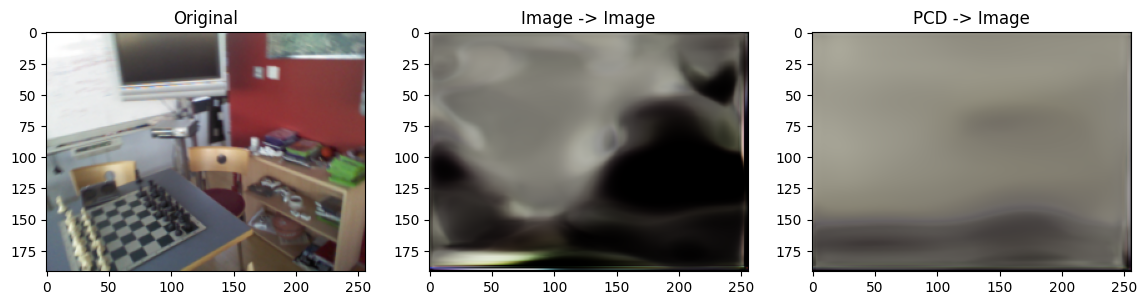

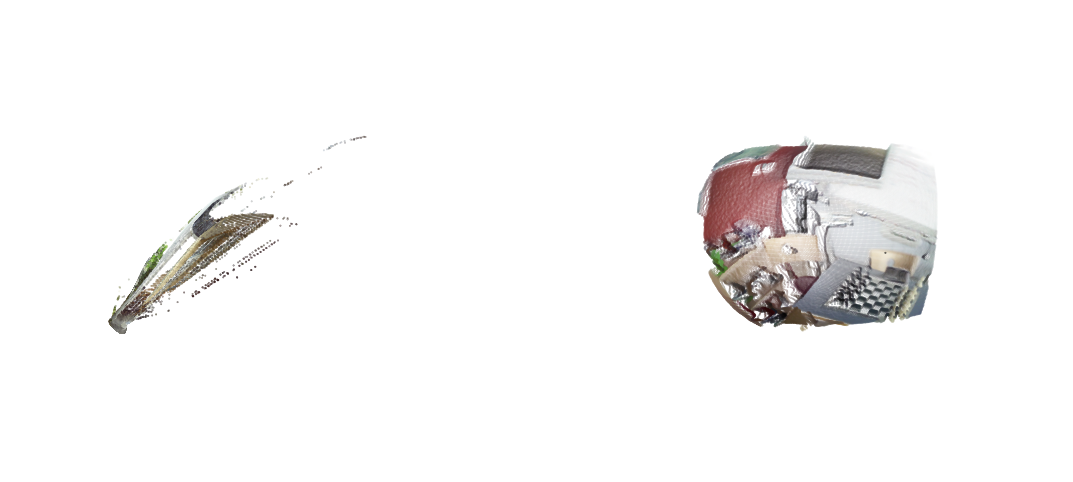

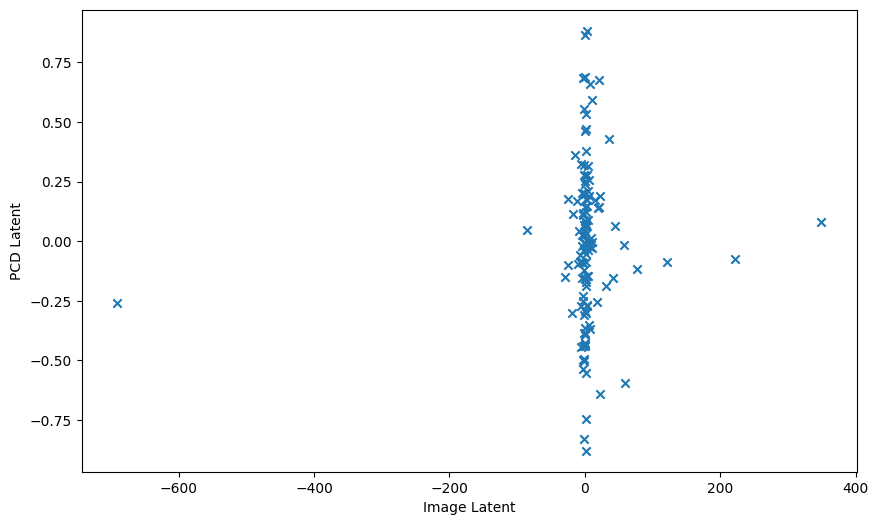

In [18]:
## Visualization
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1,3,figsize=(14,6))
ax[0].imshow(img_in)
ax[0].set_title('Original')
ax[1].imshow(img_img)
ax[1].set_title('Image -> Image')
ax[2].imshow(pcd_img)
ax[2].set_title('PCD -> Image')
fig.show()

fig = plt.figure(figsize=(14, 6))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax1 = fig.add_subplot(1, 2, 2, projection="3d")
ax0.scatter(-pcd_in[:,0],pcd_in[:,1],pcd_in[:,2],c=pcd_in[:,4:],s=0.1)
ax1.scatter(-pcd_pcd[:,0],pcd_pcd[:,1],pcd_pcd[:,2],c=pcd_pcd[:,4:],s=0.1)

ax0.grid(False)
ax0.set_axis_off()
ax1.grid(False)
ax1.set_axis_off()

def set_axes_equal_3d(ax, x, y, z):
    x, y, z = np.asarray(x), np.asarray(y), np.asarray(z)
    xmid, ymid, zmid = (x.min()+x.max())/2, (y.min()+y.max())/2, (z.min()+z.max())/2
    r = 0.5 * max(x.max()-x.min(), y.max()-y.min(), z.max()-z.min())
    ax.set_xlim(xmid - r, xmid + r)
    ax.set_ylim(ymid - r, ymid + r)
    ax.set_zlim(zmid - r, zmid + r)
all_xyz = np.vstack([pcd_in[:, :4], pcd_pcd[:, :4]])
X, Y, Z = all_xyz[:,0], all_xyz[:,1], all_xyz[:,2]

for ax in (ax0, ax1):
    #set_axes_equal_3d(ax, -X, -Y, Z)
    #ax.view_init(elev=5, azim=25)
    ax.view_init(elev=3, azim=-20)
plt.savefig('../gnn_spatial_reasoning/figures/pcd_7s.png',dpi=900)

fig.show()

plt.figure(figsize=(10,6))
plt.xlabel('Image Latent')
plt.ylabel('PCD Latent')
plt.scatter(pred['z_img'],pred['z_pcd'],marker='x')

In [17]:
# interactive point cloud
import plotly.graph_objects as go
import numpy as np
import torch

def to_np(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return x

def interactive_pcd(points, title="Point Cloud"):
    pts = to_np(points)
    xyz = pts[:, :3]
    rgb = pts[:, 4:7] if pts.shape[1] >= 7 else np.ones((pts.shape[0], 3)) * 0.7
    rgb = np.clip(rgb, 0, 1)

    fig = go.Figure(data=[go.Scatter3d(
        x=-xyz[:, 0],
        y= xyz[:, 1],
        z= xyz[:, 2],
        mode="markers",
        marker=dict(
            size=2,
            color=(rgb * 255).astype(np.uint8),
            opacity=0.9,
        )
    )])

    fig.update_layout(
        title=title,
        scene=dict(aspectmode="data"),
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()

interactive_pcd(pcd_in, "Ground Truth")
interactive_pcd(pcd_pcd, "Generated")

(-0.5, 255.5, 191.5, -0.5)

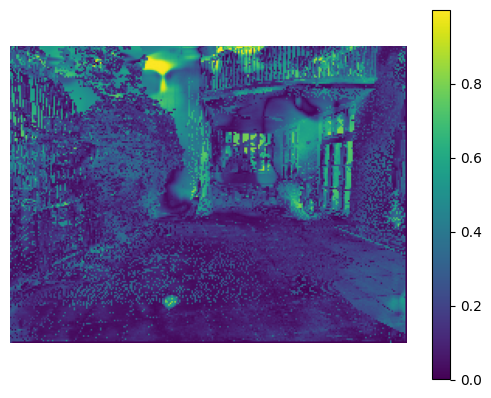

In [69]:
i = 0
d = (img_img.permute(2,0,1) - img_in.permute(2,0,1)).abs().detach().cpu()     # [3,H,W]
dmap = d.mean(dim=0)                            # [H,W]
plt.imshow(dmap)                                # expect mostly dark if L1=0.005 is real
plt.colorbar()
plt.axis("off")


In [ ]:
# graph laplacian
import torch_geometric.transforms as T
from torch_geometric.data import Data

pcd_in_data = Data()
pcd_in_data.x = batch['pcd']
pcd_in_data.edge_index = batch['edge_index']
pcd_in_data.edge_weights = batch['edge_weights']
#pe = T.AddLaplacianEigenvectorPE(12,'laplacian',is_undirected=True)
pe = T.AddRandomWalkPE(4,'laplacian')
pcd_in_data = pe(pcd_in_data)
lap_enc = pcd_in_data.laplacian

pred['pcd_pcd'] = pe(pred['pcd_pcd'])
lap_enc_pcd_pcd = pred['pcd_pcd'].laplacian

pred['img_pcd'] = pe(pred['img_pcd'])
lap_enc_img_pcd = pred['img_pcd'].laplacian

for e in range(12):
    fig = plt.figure(figsize=(14, 6))
    ax0 = fig.add_subplot(1, 3, 1, projection="3d")
    ax1 = fig.add_subplot(1, 3, 2, projection="3d")
    ax2 = fig.add_subplot(1, 3, 3, projection="3d")
    ax0.scatter(pcd_in[:,0],pcd_in[:,1],-pcd_in[:,2],c=lap_enc[:,e])
    ax1.scatter(pcd_pcd[:,0],pcd_pcd[:,1],-pcd_pcd[:,2],c=lap_enc_pcd_pcd[:,e])
    ax2.scatter(img_pcd[:,0],img_pcd[:,1],-img_pcd[:,2],c=lap_enc_img_pcd[:,e])
    fig.show()
    #break

/cluster/home/btuncay/gnn_312/lib/python3.12/site-packages/torch_geometric/utils/sparse.py:276: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  adj = torch.sparse_csr_tensor(
